In [11]:
import numpy as np

# Define Pauli matrices
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

bell_state = (1/np.sqrt(2)) * (np.array([1, 0, 0, 1]))

def expectation(state, operator):
    return np.vdot(state, operator @ state).real

chsh_operator = np.kron(sigma_x, sigma_x) + np.kron(sigma_x, sigma_z) + \
                np.kron(sigma_z, sigma_x) - np.kron(sigma_z, sigma_z)

# Calculate expectation
expectation_value = expectation(bell_state, chsh_operator)

print(f"CHSH Expectation Value: {expectation_value}")

CHSH Expectation Value: 0.0


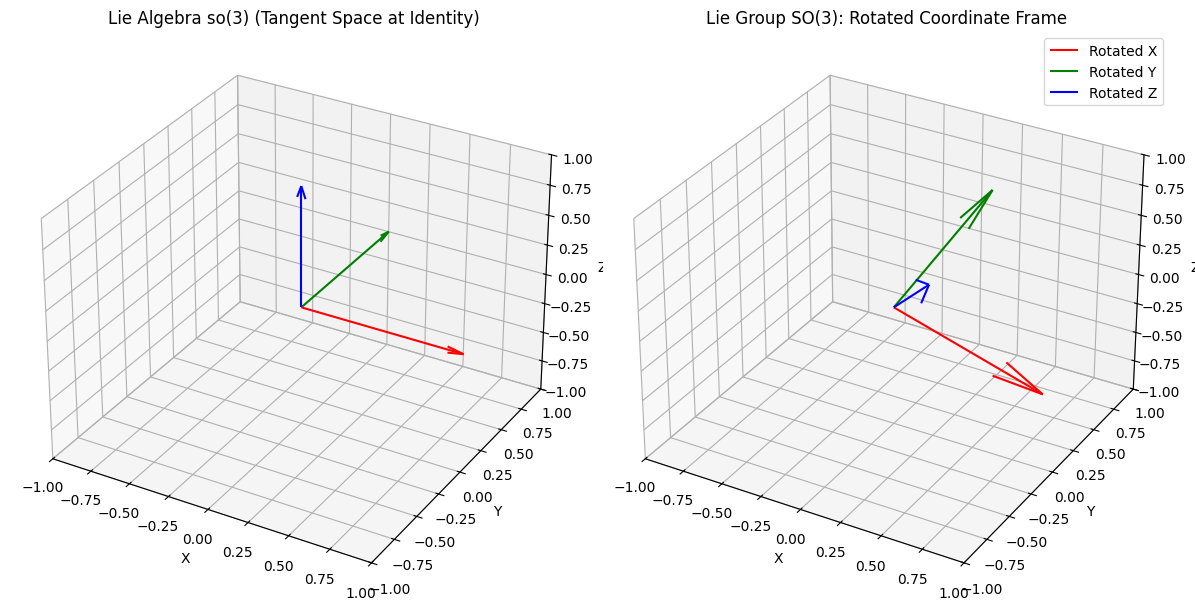

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import expm

def skew(vector):
    """
    Returns the 3x3 skew-symmetric matrix ("hat" operator)
    corresponding to a 3D vector.
    """
    x, y, z = vector
    return np.array([[0, -z, y],
                     [z, 0, -x],
                     [-y, x, 0]])

def rotation_from_axis_angle(axis, theta):
    """
    Computes a rotation matrix from an axis and angle using the 
    exponential map exp(theta * K) where K is the skew-symmetric 
    matrix corresponding to the axis.
    """
    axis = axis / np.linalg.norm(axis)
    K = skew(axis)
    return expm(theta * K)

def plot_rotation_matrix(R, ax):
    """
    Plots the rotated coordinate frame defined by rotation matrix R.
    The original coordinate axes are the unit vectors in x, y, z directions.
    """
    origin = np.array([0, 0, 0])
    # Rotate standard basis vectors
    x_axis = R @ np.array([1, 0, 0])
    y_axis = R @ np.array([0, 1, 0])
    z_axis = R @ np.array([0, 0, 1])
    
    # Plot rotated axes using quiver
    ax.quiver(*origin, *x_axis, color='r', label='Rotated X')
    ax.quiver(*origin, *y_axis, color='g', label='Rotated Y')
    ax.quiver(*origin, *z_axis, color='b', label='Rotated Z')
    
    # Set the plot limits and labels
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()

if __name__ == "__main__":
    # Create a figure with two subplots: one for the Lie algebra and one for the Lie group.
    fig = plt.figure(figsize=(12, 6))
    
    # Subplot 1: Visualizing the Lie algebra so(3)
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_title("Lie Algebra so(3) (Tangent Space at Identity)")
    # We'll represent three basic directions (basis vectors in R^3)
    basis_vectors = np.array([[1, 0, 0],
                              [0, 1, 0],
                              [0, 0, 1]])
    colors = ['r', 'g', 'b']
    for vec, color in zip(basis_vectors, colors):
        ax1.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=color, arrow_length_ratio=0.1)
    ax1.set_xlim([-1, 1])
    ax1.set_ylim([-1, 1])
    ax1.set_zlim([-1, 1])
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # Subplot 2: Visualizing an element of the Lie group SO(3)
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_title("Lie Group SO(3): Rotated Coordinate Frame")
    
    # Define a rotation by choosing an axis and an angle.
    axis = np.array([1, 1, 0])
    theta = np.pi / 4  # 45 degrees rotation
    R = rotation_from_axis_angle(axis, theta)
    
    # Plot the rotated coordinate frame using our rotation matrix.
    plot_rotation_matrix(R, ax2)
    
    plt.tight_layout()
    plt.show()

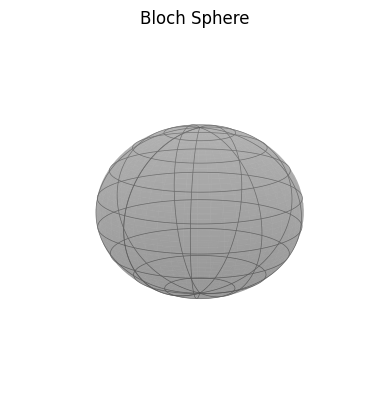

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_bloch_vector(theta, phi):
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Draw Bloch sphere
    u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:50j]
    xs = np.sin(v) * np.cos(u)
    ys = np.sin(v) * np.sin(u)
    zs = np.cos(v)
    # ax.plot(xs.flatten(), ys.flatten(), zs.flatten(), color="red")
    # ax.plot_surface(xs, ys, zs, color='lightblue', alpha=0.3)
    ax.plot_surface(xs, ys, zs, color='gray', alpha=0.3)

    # u, v = np.mgrid[0:np.pi:50j, 0:2*np.pi:10j]
    u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:10j]
    ut = u.T
    vt = v.T
    u, v = np.mgrid[0:2*np.pi:10j, 0:np.pi:100j]
    xs = np.sin(v) * np.cos(u)
    ys = np.sin(v) * np.sin(u)
    zs = np.cos(v)
    xst = np.sin(vt) * np.cos(ut)
    yst = np.sin(vt) * np.sin(ut)
    zst = np.cos(vt)
    for i, x in enumerate(xst):
        ax.plot(x, yst[i], zst[i], color="gray", lw=0.5)

    for i, x in enumerate(xs):
        ax.plot(xs[i], ys[i], zs[i], color="gray", lw=0.5)
    
    

    # Draw vector
    # ax.quiver(0, 0, 0, x, y, z, color='k', linewidth=2)

    # Set labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Bloch Sphere')
    ax.grid(False)
    ax.set_axis_off()
    ax.view_init(15,45,0)
    # ax.set_aspect("equal")
    plt.show()

# Example usage: |0> state
plot_bloch_vector(0, 0)

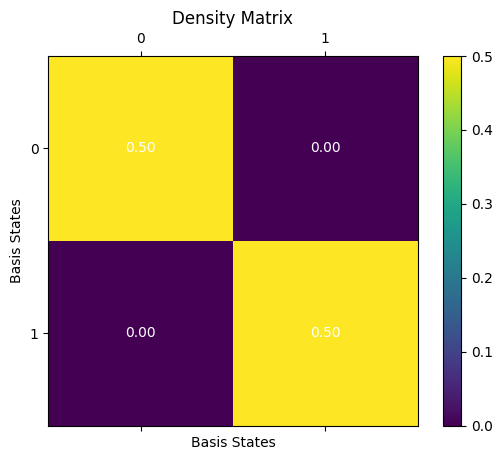

In [13]:
def plot_density_matrix(rho):
    fig, ax = plt.subplots()
    cax = ax.matshow(rho, cmap='viridis')
    fig.colorbar(cax)
    for (i, j), val in np.ndenumerate(rho):
        ax.text(j, i, f"{val.real:.2f}", ha='center', va='center', color='white')
    plt.title('Density Matrix')
    plt.xlabel('Basis States')
    plt.ylabel('Basis States')
    plt.show()

# Example usage: Mixed state
rho = 0.5 * np.array([[1, 0], [0, 1]])
plot_density_matrix(rho)

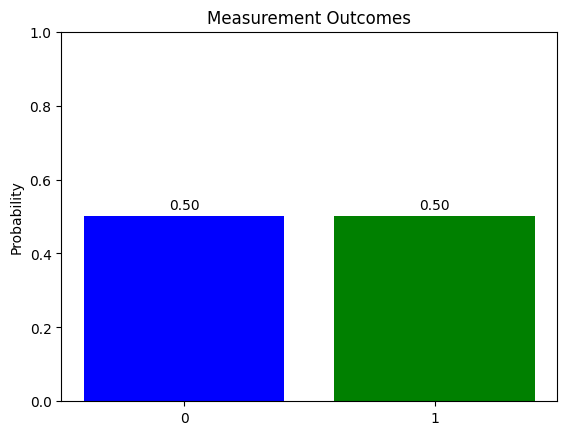

In [14]:
def plot_measurement_outcomes(probabilities, labels=['0', '1']):
    fig, ax = plt.subplots()
    ax.bar(labels, probabilities, color=['blue', 'green'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability')
    ax.set_title('Measurement Outcomes')
    for i, prob in enumerate(probabilities):
        ax.text(i, prob + 0.02, f"{prob:.2f}", ha='center')
    plt.show()

# Example usage: |+> state measurement in Z-basis
probabilities = [0.5, 0.5]
plot_measurement_outcomes(probabilities)

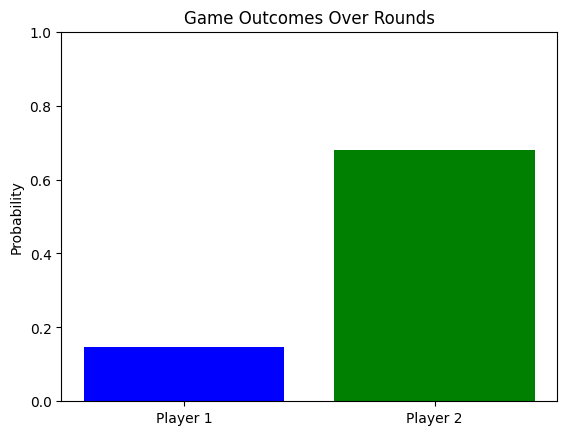

In [15]:
import matplotlib.animation as animation

def animate_game_rounds(rounds, outcomes):
    fig, ax = plt.subplots()
    bars = ax.bar(['Player 1', 'Player 2'], [0, 0], color=['blue', 'green'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability')
    ax.set_title('Game Outcomes Over Rounds')

    def animate(i):
        bars[0].set_height(outcomes[i][0])
        bars[1].set_height(outcomes[i][1])
        return bars

    ani = animation.FuncAnimation(fig, animate, frames=rounds, interval=500, blit=True, repeat=False)
    plt.show()

# Example usage: Simulate 10 rounds with random outcomes
import random
rounds = 10
outcomes = [(random.random(), random.random()) for _ in range(rounds)]
animate_game_rounds(rounds, outcomes)

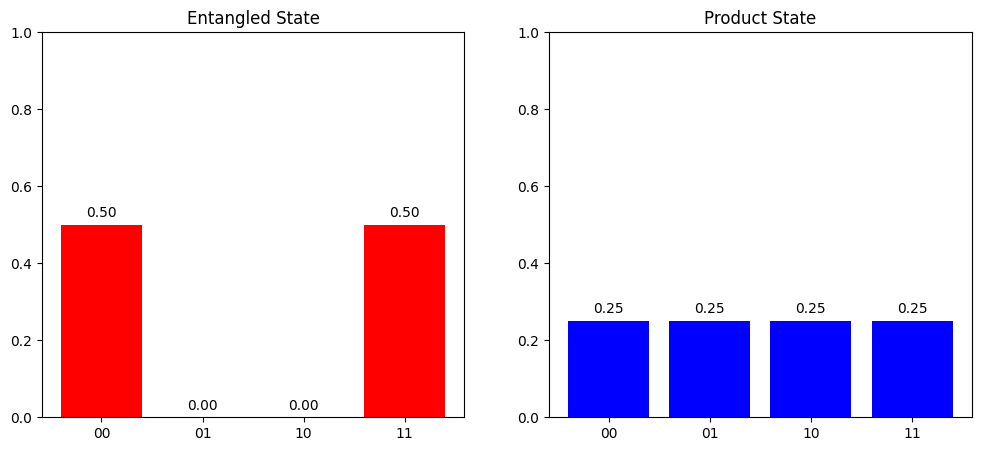

In [16]:
def plot_entangled_vs_product(entangled_probs, product_probs, labels=['00', '01', '10', '11']):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    # Entangled State
    axs[0].bar(labels, entangled_probs, color='red')
    axs[0].set_ylim(0, 1)
    axs[0].set_title('Entangled State')
    for i, prob in enumerate(entangled_probs):
        axs[0].text(i, prob + 0.02, f"{prob:.2f}", ha='center')
    
    # Product State
    axs[1].bar(labels, product_probs, color='blue')
    axs[1].set_ylim(0, 1)
    axs[1].set_title('Product State')
    for i, prob in enumerate(product_probs):
        axs[1].text(i, prob + 0.02, f"{prob:.2f}", ha='center')
    
    plt.show()

# Example usage:
entangled_probs = [0.5, 0, 0, 0.5]
product_probs = [0.25, 0.25, 0.25, 0.25]
plot_entangled_vs_product(entangled_probs, product_probs)

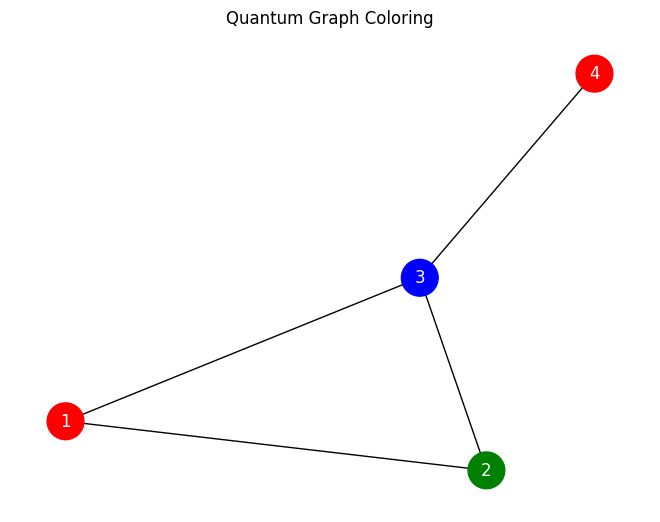

In [17]:
import networkx as nx

def plot_graph_coloring(edges, coloring, title='Graph Coloring'):
    G = nx.Graph()
    G.add_edges_from(edges)
    colors = [coloring.get(node, 'gray') for node in G.nodes()]
    
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=700, font_color='white')
    plt.title(title)
    plt.show()

# Example usage:
edges = [(1, 2), (2, 3), (3, 1), (3, 4)]
coloring = {1: 'red', 2: 'green', 3: 'blue', 4: 'red'}
plot_graph_coloring(edges, coloring, 'Quantum Graph Coloring')

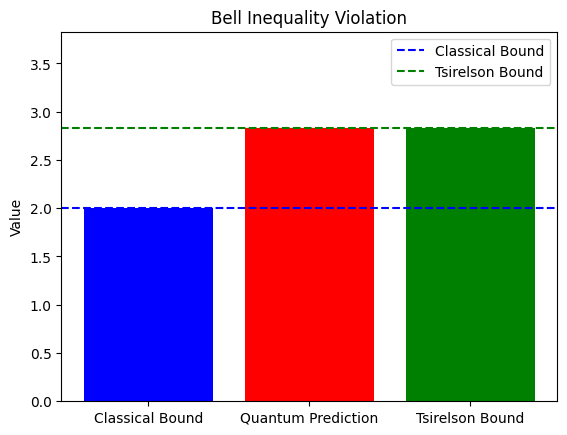

In [18]:
def plot_bell_inequality(classical_bound, quantum_value, tsirelson_bound):
    labels = ['Classical Bound', 'Quantum Prediction', 'Tsirelson Bound']
    values = [classical_bound, quantum_value, tsirelson_bound]
    colors = ['blue', 'red', 'green']
    
    fig, ax = plt.subplots()
    ax.bar(labels, values, color=colors)
    ax.axhline(y=classical_bound, color='blue', linestyle='--', label='Classical Bound')
    ax.axhline(y=tsirelson_bound, color='green', linestyle='--', label='Tsirelson Bound')
    ax.set_ylim(0, max(values) + 1)
    ax.set_ylabel('Value')
    ax.set_title('Bell Inequality Violation')
    ax.legend()
    plt.show()

# Example usage:
classical_bound = 2
quantum_value = 2.828  # 2√2, Tsirelson's bound
tsirelson_bound = 2.828
plot_bell_inequality(classical_bound, quantum_value, tsirelson_bound)

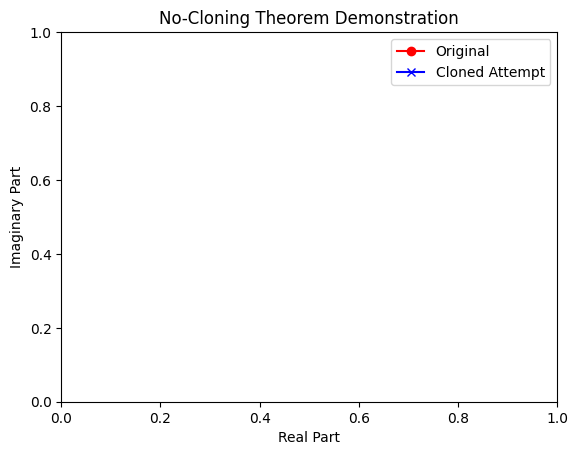

In [19]:
def animate_no_cloning(original_state, cloned_state, iterations=10):
    fig, ax = plt.subplots()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    line1, = ax.plot([], [], 'ro-', label='Original')
    line2, = ax.plot([], [], 'bx-', label='Cloned Attempt')
    ax.legend()
    ax.set_title('No-Cloning Theorem Demonstration')
    ax.set_xlabel('Real Part')
    ax.set_ylabel('Imaginary Part')

    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        return line1, line2,

    def animate(i):
        # Simulate degradation of cloned state
        fidelity = 1 - i * (1/iterations)
        cloned = cloned_state * fidelity
        line1.set_data(original_state.real, original_state.imag)
        line2.set_data(cloned.real, cloned.imag)
        return line1, line2,

    ani = animation.FuncAnimation(fig, animate, init_func=init,
                                  frames=iterations, interval=500, blit=True, repeat=False)
    plt.show()

# Example usage:
original_state = np.array([1+0j, 0+0j])  # |0> state
cloned_state = np.array([1+0j, 0+0j])  # Attempted clone
animate_no_cloning(original_state, cloned_state)

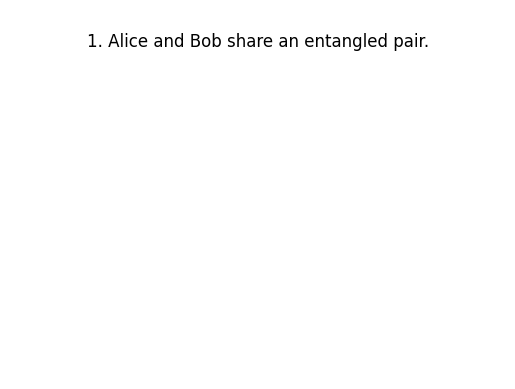

In [20]:
def visualize_dense_coding():
    fig, ax = plt.subplots()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    steps = [
        "1. Alice and Bob share an entangled pair.",
        "2. Alice applies a unitary operation based on her 2-bit message.",
        "3. Alice sends her qubit to Bob.",
        "4. Bob performs a joint measurement to retrieve the message."
    ]
    
    for i, step in enumerate(steps):
        ax.text(5, 9 - i*2, step, fontsize=12, ha='center')
        plt.pause(2)
    
    plt.show()

# Example usage:
visualize_dense_coding()

In [10]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt

# Initialize a quantum circuit with 2 qubits
qc = QuantumCircuit(2)

# Prepare an arbitrary qubit state
qc.h(0)  # Apply Hadamard to create superposition

# Attempt to clone the state (which should fail)
qc.cx(0, 1)  # CNOT gate as a cloning attempt

# Visualize the circuit
print(qc.draw())

# Execute the circuit
backend = Aer.get_backend('statevector_simulator')
result = transpile(qc, backend)#.result()
state = Statevector(result)


# Display the state vector
print(state)

# Plot the Bloch sphere for both qubits
from qiskit.visualization import plot_bloch_multivector

plot_bloch_multivector(state)
plt.show()


     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


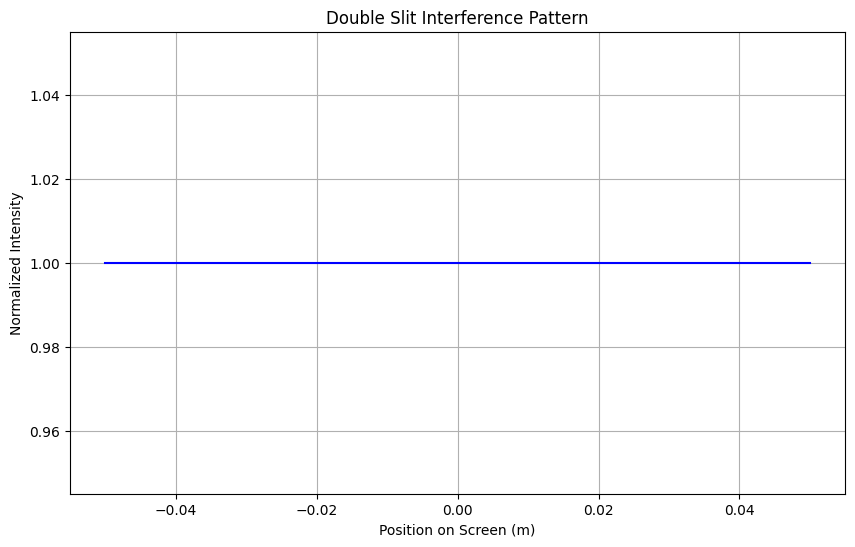

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def plot_interference_pattern(wavelength, slit_distance, screen_distance, num_particles=1000):
    # Constants
    k = 2 * np.pi / wavelength
    
    # Position array on the screen
    x = np.linspace(-0.05, 0.05, 1000)  # 5 cm range
    intensity = np.zeros_like(x)
    
    # Calculate interference pattern
    for xi in x:
        # Path difference
        delta = slit_distance * xi / screen_distance
        # Superposition of two wave amplitudes
        amplitude = np.exp(1j * k * delta / 2) + np.exp(-1j * k * delta / 2)
        intensity_val = np.abs(amplitude)**2
        intensity += intensity_val
    
    # Normalize intensity
    intensity /= np.max(intensity)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, intensity, color='blue')
    plt.title('Double Slit Interference Pattern')
    plt.xlabel('Position on Screen (m)')
    plt.ylabel('Normalized Intensity')
    plt.grid(True)
    plt.show()

# Example usage:
plot_interference_pattern(wavelength=500e-9, slit_distance=1e-5, screen_distance=1.0)

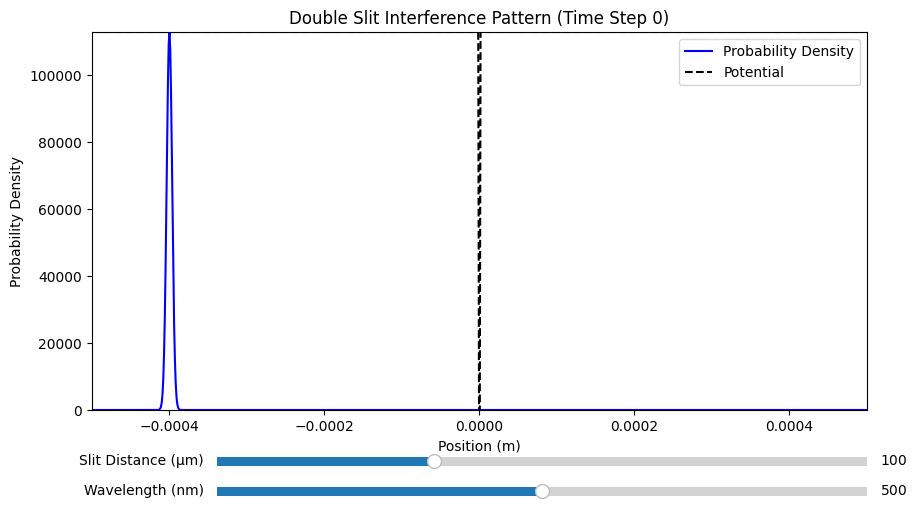

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.sparse import diags
from scipy.sparse.linalg import splu
from matplotlib.widgets import Slider

# Physical Constants
hbar = 1.0545718e-34        # Reduced Planck's constant (J·s)
m = 9.10938356e-31          # Mass of electron (kg)

# Spatial Parameters
x_min = -0.0005              # Minimum x (meters)
x_max = 0.0005               # Maximum x (meters)
N = 1000                     # Number of spatial points
dx = (x_max - x_min) / N     # Spatial step (meters)
x = np.linspace(x_min, x_max, N)

# Time Parameters
dt = 1e-18                   # Time step (seconds)
T = 2e-15                    # Total simulation time (seconds)
num_steps = int(T / dt)

# Potential Parameters (Double Slit)
V0 = 1e-18                   # Potential barrier height (J)
slit_width = 1e-6            # Width of each slit (meters)
slit_position = 0.0          # Position of slits (meters)
slit_separation = 1e-6       # Separation between slits (meters)
barrier_height = V0          # Height of potential barrier

def create_double_slit_potential(x, barrier_height, slit_width, slit_position=0.0, slit_separation=1e-6):
    V = barrier_height * np.ones_like(x)
    slit1 = np.abs(x - (slit_position - slit_separation/2)) < slit_width/2
    slit2 = np.abs(x - (slit_position + slit_separation/2)) < slit_width/2
    V[slit1] = 0.0
    V[slit2] = 0.0
    return V

V = create_double_slit_potential(x, barrier_height, slit_width, slit_position, slit_separation)

def initialize_wavepacket(x, x0, k0, sigma):
    Psi = (1/(sigma * np.sqrt(np.pi)))**0.5 * np.exp(-(x - x0)**2 / (2 * sigma**2)) * np.exp(1j * k0 * x)
    Psi /= np.sqrt(np.sum(np.abs(Psi)**2) * dx)
    return Psi

# Parameters for the initial wave packet
x0 = -0.0004          # Initial position (meters)
k0 = 1e7              # Initial wave number (rad/m)
sigma = 5e-6          # Width of the wave packet (meters)

Psi0 = initialize_wavepacket(x, x0, k0, sigma)

# Kinetic energy coefficient
a = hbar**2 / (2 * m * dx**2)

# Create the Hamiltonian matrices for Crank-Nicolson
def create_crank_nicolson_matrices(x, V, a, dt, hbar):
    # Matrix A
    main_diag_A = (1 + 1j * a * dt / (2 * hbar)) + 1j * dt * V / (2 * hbar)
    off_diag_A = -0.5j * a * dt / (2 * hbar) * np.ones(N-1, dtype=complex)
    diagonals_A = [main_diag_A, off_diag_A, off_diag_A]
    A = diags(diagonals_A, [0, -1, 1], format='csc')
    
    # Matrix B
    main_diag_B = (1 - 1j * a * dt / (2 * hbar)) - 1j * dt * V / (2 * hbar)
    off_diag_B = 0.5j * a * dt / (2 * hbar) * np.ones(N-1, dtype=complex)
    diagonals_B = [main_diag_B, off_diag_B, off_diag_B]
    B = diags(diagonals_B, [0, -1, 1], format='csc')
    
    return A, B

A, B = create_crank_nicolson_matrices(x, V, a, dt, hbar)
LU_A = splu(A)

def time_evolution_crank_nicolson_record(Psi0, V, A, B, LU_A, num_steps, record_interval=100):
    Psi = Psi0.copy()
    Psi_records = []
    for step in range(num_steps):
        b = B.dot(Psi)
        Psi = LU_A.solve(b)
        norm = np.sqrt(np.sum(np.abs(Psi)**2) * dx)
        Psi /= norm
        if step % record_interval == 0:
            Psi_records.append(Psi.copy())
    return Psi_records

# Perform time evolution and record wavefunctions
record_interval = 50  # Record every 50 time steps
Psi_records = time_evolution_crank_nicolson_record(Psi0, V, A, B, LU_A, num_steps, record_interval)
prob_density_records = [np.abs(Psi)**2 for Psi in Psi_records]

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.25)  # Make space for sliders

# Initial plots
line_prob, = ax.plot(x, prob_density_records[0], color='blue', label='Probability Density')
line_pot, = ax.plot(x, V / np.max(V) * np.max(prob_density_records[0]), color='black', linestyle='--', label='Potential')
ax.set_xlim(x_min, x_max)
ax.set_ylim(0, np.max(prob_density_records))
ax.set_title('Double Slit Interference Pattern with Potential')
ax.set_xlabel('Position (m)')
ax.set_ylabel('Probability Density')
ax.legend()

# Add sliders for wavelength and slit distance
ax_wavelength = plt.axes([0.25, 0.1, 0.65, 0.03])
slider_wavelength = Slider(ax_wavelength, 'Wavelength (nm)', 300, 700, valinit=500)

ax_slit = plt.axes([0.25, 0.15, 0.65, 0.03])
slider_slit = Slider(ax_slit, 'Slit Distance (μm)', 50, 200, valinit=100)

def update_parameters(val):
    global V, probabilities, prob_density_records, Psi_records, line_theory
    # Update physical parameters based on sliders
    new_wavelength = slider_wavelength.val * 1e-9      # Convert nm to meters
    new_slit_distance = slider_slit.val * 1e-6        # Convert μm to meters
    
    # Update potential
    V_new = create_double_slit_potential(x, barrier_height, slit_width, slit_position, new_slit_distance)
    
    # Recreate Hamiltonian matrices
    A_new, B_new = create_crank_nicolson_matrices(x, V_new, a, dt, hbar)
    LU_A_new = splu(A_new)
    
    # Reinitialize wavefunction
    Psi0_new = initialize_wavepacket(x, x0, k0, sigma)
    
    # Re-run time evolution
    Psi_records_new = time_evolution_crank_nicolson_record(Psi0_new, V_new, A_new, B_new, LU_A_new, num_steps, record_interval)
    prob_density_records_new = [np.abs(Psi)**2 for Psi in Psi_records_new]
    
    # Update global variables
    V[:] = V_new
    Psi_records[:] = Psi_records_new
    prob_density_records[:] = prob_density_records_new
    
    # Update the plot
    line_prob.set_ydata(prob_density_records[0])
    line_pot.set_ydata(V / np.max(V) * np.max(prob_density_records[0]))
    ax.set_ylim(0, np.max(prob_density_records))
    fig.canvas.draw_idle()

slider_wavelength.on_changed(update_parameters)
slider_slit.on_changed(update_parameters)

# Define the animation function
def animate(i):
    if i >= len(prob_density_records):
        ani.event_source.stop()
        return line_prob, line_pot
    line_prob.set_ydata(prob_density_records[i])
    line_pot.set_ydata(V / np.max(V) * np.max(prob_density_records[i]))
    ax.set_title(f'Double Slit Interference Pattern (Time Step {i * record_interval})')
    return line_prob, line_pot

# Create the animation
ani = animation.FuncAnimation(fig, animate, frames=len(prob_density_records),
                              interval=100, blit=True)

plt.show()


In [30]:
qc = QuantumCircuit(1, 1)
qc.measure(0,0)

In [ ]:
np.random.seed(0)
cards = [1,2,3]
num_rounds = 100000
wins_cbit = 0
wins_qubit = 0

def classical_bit_strategy(X1, X2):  
    cbit = 0 if X1 in [1, 2] else 1

    if cbit == 0:
        Y_Z = 1 if X2 in [1, 2] else 0
    else:
        Y_Z = 1 if X2 == 3 else 0

    if (Y_Z == 1 and X1 == X2) or (Y_Z == 0 and X1 != X2):
        return 1  # Win
    else:
        return 0  # Lose
    
def quantum_bit_strategy(X1, X2):
    state_1 = np.array([1,0], dtype=complex)
    state_2 = np.array([0,1], dtype=complex)
    if X1 == 1:
        state = state_1
    elif X1 == 2:
        state = state_2
    else:
        state = 1/(2**0.5)*(state_1+state_2)
    